In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, to_date
import matplotlib.pyplot as plt

spark = SparkSession.builder.master("local[*]").appName("DataWarehouseVendas").getOrCreate()

df_vendedores = spark.read.option("header", True).csv("data/Vendedores.csv")
df_transportadoras = spark.read.option("header", True).csv("data/Transportadoras.csv")
df_fornecedores = spark.read.option("header", True).csv("data/Fornecedores.csv")
df_vendas = spark.read.option("header", True).csv("data/Vendas Globais.csv")

from pyspark.sql.types import DoubleType, IntegerType, DateType

df_vendas = df_vendas.withColumn("Vendas Custo", col("Vendas Custo").cast(DoubleType())) \
                     .withColumn("Margem Bruta", col("Margem Bruta").cast(DoubleType())) \
                     .withColumn("Vendas", col("Vendas").cast(DoubleType())) \
                     .withColumn("Desconto", col("Desconto").cast(DoubleType())) \
                     .withColumn("Frete", col("Frete").cast(DoubleType())) \
                     .withColumn("Qtde", col("Qtde").cast(IntegerType())) \
                     .withColumn("PedidoID", col("PedidoID").cast(IntegerType()))

df_vendas = df_vendas.withColumn("VendedorID", col("VendedorID").cast(IntegerType())) \
                     .withColumn("TransportadoraID", col("TransportadoraID").cast(IntegerType())) \
                     .withColumn("FornecedorID", col("FornecedorID").cast(IntegerType()))

dim_vendedores = df_vendedores.dropDuplicates(["VendedorID"])
dim_transportadoras = df_transportadoras.dropDuplicates(["TransportadoraID"])
dim_fornecedores = df_fornecedores.dropDuplicates(["FornecedorID"])

dim_clientes = df_vendas.select("ClienteID", "ClienteNome", "ClienteContato", "ClienteCidade", "ClientePaísID", "ClientePaís").dropDuplicates(["ClienteID"])
dim_produtos = df_vendas.select("ProdutoID", "ProdutoNome", "CategoriaID", "CategoriaNome", "CategoriaDescrição").dropDuplicates(["ProdutoID"])
dim_categorias = df_vendas.select("CategoriaID", "CategoriaNome", "CategoriaDescrição").dropDuplicates(["CategoriaID"])

fato_vendas = df_vendas.select(
    "PedidoID", "Data", "VendedorID", "TransportadoraID", "FornecedorID", "ClienteID", "ProdutoID",
    "Vendas Custo", "Margem Bruta", "Vendas", "Desconto", "Frete", "Qtde"
)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/28 12:29:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


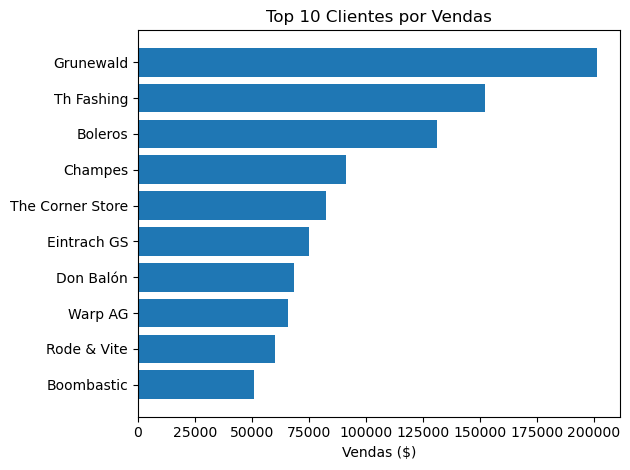

In [2]:
#1. Quem são os meus 10 maiores clientes, em termos de vendas ($)?
top_ten = fato_vendas.join(dim_clientes, "ClienteID") \
    .groupBy("ClienteNome") \
    .sum("Vendas") \
    .orderBy("sum(Vendas)", ascending=False) \
    .limit(10) \
    .toPandas()
    
fig, ax = plt.subplots()
ax.barh(top_ten['ClienteNome'], top_ten['sum(Vendas)'])
ax.invert_yaxis()  
ax.set_xlabel('Vendas ($)')
ax.set_title('Top 10 Clientes por Vendas')
plt.tight_layout()
plt.show()

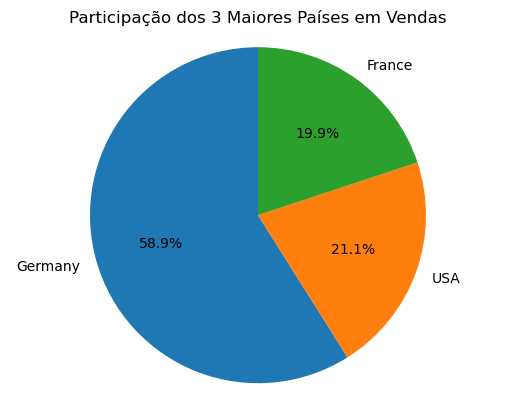

In [3]:
#2. Quais os três maiores países, em termos de vendas ($)?
top_countries = fato_vendas.join(dim_clientes, "ClienteID") \
    .groupBy("ClientePaís") \
    .sum("Vendas") \
    .orderBy("sum(Vendas)", ascending=False) \
    .limit(3) \
    .toPandas()

fig, ax = plt.subplots()
ax.pie(
    top_countries['sum(Vendas)'],
    labels=top_countries['ClientePaís'],
    autopct='%1.1f%%',
    startangle=90
)
ax.set_title('Participação dos 3 Maiores Países em Vendas')
ax.axis('equal') 
plt.show()

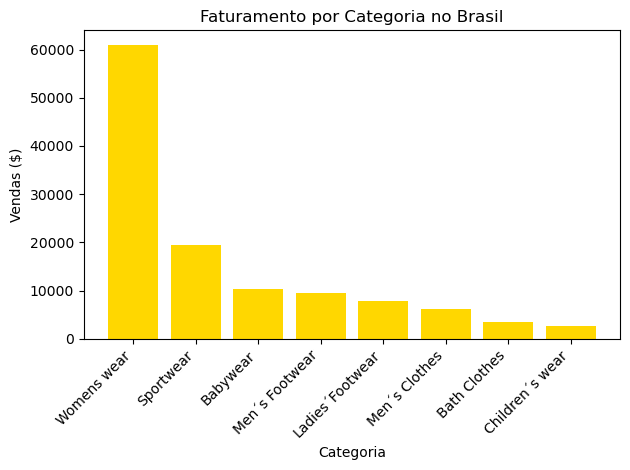

In [4]:
#3. Quais as categorias de produtos que geram maior faturamento (vendas $) no Brasil?
best_product = fato_vendas.join(dim_clientes, "ClienteID") \
    .join(dim_produtos, "ProdutoID") \
    .filter(col("ClientePaís") == "Brazil") \
    .groupBy("CategoriaNome") \
    .sum("Vendas") \
    .orderBy("sum(Vendas)", ascending=False) \
    .toPandas()

fig, ax = plt.subplots()
ax.bar(best_product['CategoriaNome'], best_product['sum(Vendas)'], color='gold')
ax.set_xlabel('Categoria')
ax.set_ylabel('Vendas ($)')
ax.set_title('Faturamento por Categoria no Brasil')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

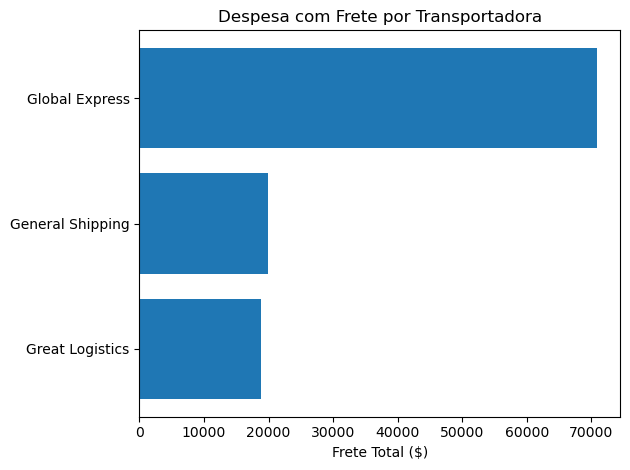

In [5]:
#4. Qual a despesa com frete envolvendo cada transportadora?
transport_tax = fato_vendas.join(dim_transportadoras, "TransportadoraID") \
    .groupBy("TransportadoraNome") \
    .sum("Frete") \
    .orderBy("sum(Frete)", ascending=False) \
    .toPandas()

fig, ax = plt.subplots()
ax.barh(
    transport_tax['TransportadoraNome'],
    transport_tax['sum(Frete)']
)
ax.invert_yaxis()
ax.set_xlabel('Frete Total ($)')
ax.set_title('Despesa com Frete por Transportadora')
plt.tight_layout()
plt.show()

          ClienteNome  sum(Vendas)
0           Grunewald   20488.4850
1         Gluderstedt   11923.3485
2          Boombastic   11235.9700
3         Eintrach GS   10377.8330
4             Warp AG    9085.7650
5    Noch Einmal GMBH    3030.7200
6     Casual Clothing    2602.5025
7          Halle Köln    1692.5580
8         Man Kleider    1108.0000
9  Kohl Industries AG     286.5600


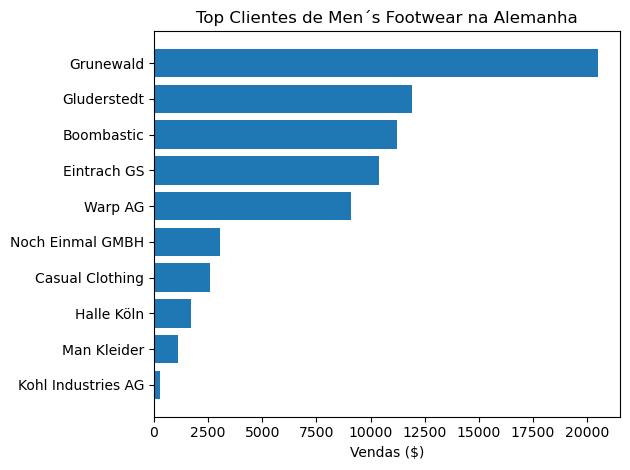

In [6]:
#5. Quais são os principais clientes (vendas $) do segmento “Calçados Masculinos”
#(Men ́s Footwear) na Alemanha?
male_princess_foot = fato_vendas.join(dim_clientes, "ClienteID") \
    .join(dim_produtos, "ProdutoID") \
    .filter((col("CategoriaNome") == "Men´s Footwear") & (col("ClientePaís") == "Germany")) \
    .groupBy("ClienteNome") \
    .sum("Vendas") \
    .orderBy("sum(Vendas)", ascending=False) \
    .toPandas()
print(male_princess_foot)
# 5. Top clientes de Men´s Footwear na Alemanha: barras horizontais
fig, ax = plt.subplots()
ax.barh(
    male_princess_foot['ClienteNome'],
    male_princess_foot['sum(Vendas)']
)
ax.invert_yaxis()
ax.set_xlabel('Vendas ($)')
ax.set_title("Top Clientes de Men´s Footwear na Alemanha")
plt.tight_layout()
plt.show()

25/04/28 12:29:48 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


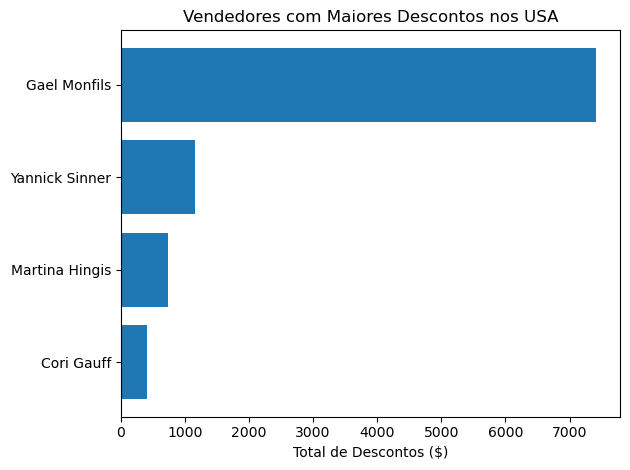

In [7]:
#6. Quais os vendedores que mais dão descontos nos Estados Unidos?
low_tax_eua = fato_vendas.join(dim_clientes, "ClienteID") \
    .join(dim_vendedores, "VendedorID") \
    .filter(col("ClientePaís") == "USA") \
    .groupBy("VendedorNome") \
    .sum("Desconto") \
    .orderBy("sum(Desconto)", ascending=False) \
    .toPandas()

fig, ax = plt.subplots()
ax.barh(
    low_tax_eua['VendedorNome'],
    low_tax_eua['sum(Desconto)']
)
ax.invert_yaxis()
ax.set_xlabel('Total de Descontos ($)')
ax.set_title('Vendedores com Maiores Descontos nos USA')
plt.tight_layout()
plt.show()


    FornecedorNome  sum(Margem Bruta)
0    Pälsii Sports         81839.9408
1       Baby Dress         20675.2166
2   Wills Surfwear         10019.1193
3   Great Outdoors          9165.0332
4    Global Outlet          4884.9949
5      L.A. Sports          2304.5883
6      Luis Vilton          2192.3847
7     Tennis Place          1845.2659
8         Netshoes          1810.7737
9        USA Jeans          1273.9987
10       Surf Trip           147.6087


<Figure size 1400x600 with 0 Axes>

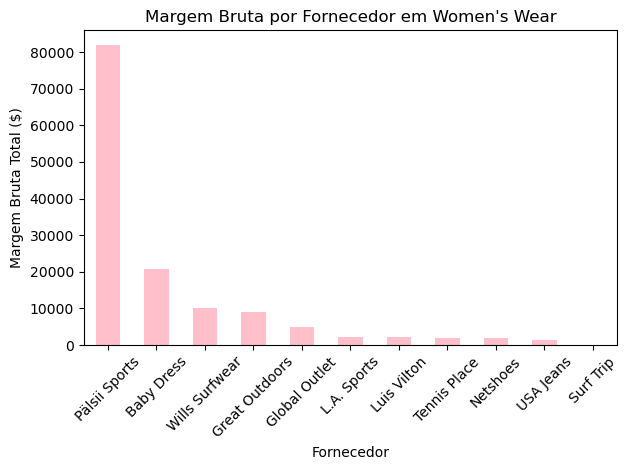

In [8]:
#7. Quais os fornecedores que dão a maior margem de lucro ($) no segmento de
#“Vestuário Feminino” (Womens wear)?
total_gain = fato_vendas.join(dim_produtos, "ProdutoID") \
    .join(dim_fornecedores, "FornecedorID") \
    .filter(col("CategoriaNome") == "Womens wear") \
    .groupBy("FornecedorNome") \
    .sum("Margem Bruta") \
    .orderBy("sum(Margem Bruta)", ascending=False) \
    .toPandas()
print(total_gain)
plt.figure(figsize=(14, 6))  

total_gain.plot.bar(
    x='FornecedorNome',
    y='sum(Margem Bruta)',
    color='pink',
    legend=False
)

plt.xlabel('Fornecedor')
plt.ylabel('Margem Bruta Total ($)')
plt.title("Margem Bruta por Fornecedor em Women's Wear")
plt.xticks(rotation=45)  
plt.tight_layout() 
plt.show()


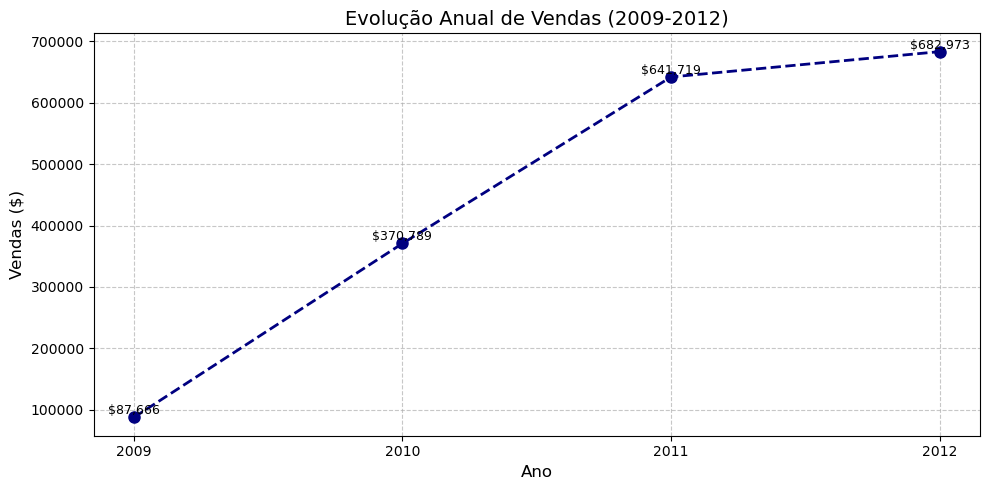

Total vendido em 2009: $87,666.29
Crescimento 2009-2010: +322.95%
Crescimento 2010-2011: +73.07%
Crescimento 2011-2012: +6.43%


In [9]:
#8. Quanto que foi vendido ($) no ano de 2009? Analisando as vendas anuais entre 2009
#e 2012, podemos concluir que o faturamento vem crescendo, se mantendo estável ou
#decaindo?

df_vendas = df_vendas.withColumn("Data", to_date(col("Data"), "dd/MM/yyyy"))

fato_vendas_with_year = df_vendas.withColumn("Ano", year(col("Data")))

vendas_2009 = fato_vendas_with_year.filter(col("Ano") == 2009) \
    .agg({"Vendas": "sum"}) \
    .collect()[0][0]

year_sold = fato_vendas_with_year.filter((col("Ano") >= 2009) & (col("Ano") <= 2012)) \
    .groupBy("Ano") \
    .sum("Vendas") \
    .orderBy("Ano") \
    .toPandas()

plt.figure(figsize=(10, 5))
plt.plot(year_sold['Ano'], year_sold['sum(Vendas)'], 
         marker='o', linestyle='--', linewidth=2, markersize=8, color='navy')

for i, (ano, venda) in enumerate(zip(year_sold['Ano'], year_sold['sum(Vendas)'])):
    plt.text(ano, venda, f"${venda:,.0f}", 
             ha='center', va='bottom', fontsize=9)

plt.xlabel('Ano', fontsize=12)
plt.ylabel('Vendas ($)', fontsize=12)
plt.title('Evolução Anual de Vendas (2009-2012)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(year_sold['Ano'])
plt.tight_layout()
plt.show()

print(f"Total vendido em 2009: ${vendas_2009:,.2f}")

for i in range(1, len(year_sold)):
    crescimento = ((year_sold['sum(Vendas)'].iloc[i] - year_sold['sum(Vendas)'].iloc[i-1]) / 
                 year_sold['sum(Vendas)'].iloc[i-1]) * 100
    print(f"Crescimento {year_sold['Ano'].iloc[i-1]}-{year_sold['Ano'].iloc[i]}: {crescimento:+.2f}%")

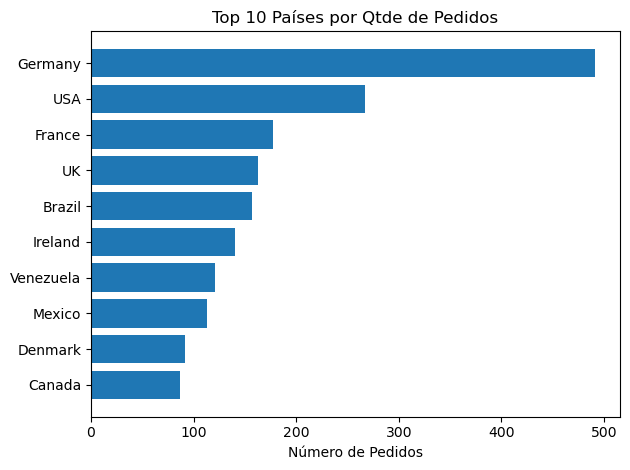

In [ ]:
#10. Quais os países nos quais mais se tiram pedidos (qtde total de pedidos)?
wish_top_contries = fato_vendas.join(dim_clientes, "ClienteID") \
    .groupBy("ClientePaís") \
    .count() \
    .orderBy("count", ascending=False) \
    .toPandas()

top_orders = wish_top_contries.head(10)
fig, ax = plt.subplots()
ax.barh(
    top_orders['ClientePaís'],
    top_orders['count']
)
ax.invert_yaxis()
ax.set_xlabel('Número de Pedidos')
ax.set_title('Top 10 Países por Qtde de Pedidos')
plt.tight_layout()
plt.show()


In [ ]:
formatos_data = [
    "dd/MM/yyyy",
    "MM/dd/yyyy",  
    "yyyy-MM-dd",   
    "dd-MM-yyyy"  
]

for formato in formatos_data:
    try:
        df_vendas = df_vendas.withColumn("Data", to_date(col("Data"), formato))
        # Verificar se a conversão foi bem sucedida
        if df_vendas.filter(col("Data").isNotNull()).count() > 0:
            print(f"Formato correto encontrado: {formato}")
            break
    except:
        continue
else:
    print("Nenhum dos formatos testados funcionou.")


Nenhum dos formatos testados funcionou. Verifique o formato real dos dados.
